# Set Up

In [1]:
import scanpy as sc
import decoupler as dc
import numpy as np

# Plotting options, change to your liking
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))

/home/workspace/environment/mm_py_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from scipy.stats import median_abs_deviation

import sys
sys.path.insert(0, '/home/workspace/')

from utilities import *

hdir = '/home/workspace'
wdir = hdir + "/mm_bm_chip_organoids/EXP-01244"
objdir = wdir + "/processing/objects/"

wk2_adata = sc.read_h5ad(objdir + "wk2_adata.h5ad")
wk3_adata = sc.read_h5ad(objdir + "wk3_adata.h5ad")
wk4_adata = sc.read_h5ad(objdir + "wk4_adata.h5ad")
ds_full_adata = sc.read_h5ad(objdir + "ds_all_samples_adata.h5ad")
no_ds_full_adata = sc.read_h5ad(objdir + "not_ds_all_samples_adata.h5ad")

adatas = [wk2_adata, wk3_adata, wk4_adata, ds_full_adata, no_ds_full_adata]

# Marker Genes

In [4]:
# Query Omnipath and get PanglaoDB
markers = dc.get_resource(
    name='PanglaoDB',
    organism='human',
    license='academic'
)
markers

,genesymbol,_entity_type,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,,
0,A0A068BD53,protein,True,B cells,Mesoderm,False,0.0,0.0,True,0.391473,0.00274026,10090,Immune system,0.007
1,A0A068BGV1,protein,True,Dendritic cells,Mesoderm,False,0.0,0.0,True,0.142857,0.000193013,10090,Immune system,0.0
2,A0A068BGW6,protein,True,B cells,Mesoderm,False,0.0,0.0,True,0.391473,0.00274026,10090,Immune system,0.007
3,A0A087WRN7,protein,False,Salivary mucous cells,Ectoderm,False,<NA>,<NA>,True,<NA>,<NA>,10090,Oral cavity,0.001
4,A0A0F6QAG2,protein,True,NK cells,Mesoderm,False,0.0,0.0,True,0.37234,0.000129107,10090,Immune system,0.002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8456,ZNF521,protein,False,Adipocyte progenitor cells,Mesoderm,True,0.0,0.0103383,False,0.0,0.0,9606,Connective tissue,0.002
8457,ZNRF4,protein,False,Germ cells,Mesoderm,True,0.28436,0.0,True,0.0,0.0,9606,Reproductive,0.01
8458,ZPBP2,protein,True,Germ cells,Mesoderm,True,0.436019,0.0,True,0.0,0.0,9606,Reproductive,0.008


In [5]:
# Filter by canonical_marker and human
markers = markers[markers['human'].astype(bool) & markers['canonical_marker'].astype(bool) & (markers['human_sensitivity'].astype(float) > 0.5)]

# Remove duplicated entries
markers = markers[~markers.duplicated(['cell_type', 'genesymbol'])]
markers

,genesymbol,_entity_type,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
,,,,,,,,,,,,,,
38,AAK1,protein,False,Neurons,Ectoderm,True,0.555556,0.0320452,True,0.470588,0.0213838,9606,Brain,0.044
50,ABCA3,protein,True,Pulmonary alveolar type II cells,Endoderm,True,0.692308,0.000943693,True,0.00757576,0.000517699,9606,Lungs,0.001
85,ACADVL,protein,False,Basal cells,Mesoderm,True,0.76,0.213018,True,1.0,0.00603183,9606,Epithelium,0.05
122,ACSL5,protein,True,Enterocytes,Endoderm,True,0.666667,0.0153798,True,0.728477,0.0501211,9606,GI tract,0.055
133,ACTA2,protein,True,Smooth muscle cells,Mesoderm,True,0.904762,0.0135604,True,1.0,0.0313632,9606,Smooth muscle,0.035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8383,WT1,protein,False,Mesothelial cells,Mesoderm,True,1.0,0.0219436,True,0.0,0.0,9606,Epithelium,0.01
8387,XCL1,protein,False,Decidual cells,<NA>,True,1.0,0.00971482,True,0.0,0.0,9606,Reproductive,0.006
8389,XCL2,protein,False,Decidual cells,<NA>,True,1.0,0.0103416,False,0.0,0.0,9606,Reproductive,0.002


# Enrichment with Over Representation Analysis (ORA)

In [7]:
dc.run_ora(
    mat=wk2_adata,
    net=markers,
    source='cell_type',
    target='genesymbol',
    min_n=3,
    verbose=True,
    use_raw=False
)

1212 features of mat are empty, they will be removed.
Running ora on mat with 25138 samples and 16870 targets for 64 sources.


100%|██████████| 25138/25138 [00:59<00:00, 419.99it/s]


In [9]:
wk2_adata.obsm['ora_estimate']

source,Acinar cells,Adipocytes,Alpha cells,Astrocytes,B cells,B cells naive,Basal cells,Beta cells,Cholangiocytes,Clara cells,...,Proximal tubule cells,Pulmonary alveolar type II cells,Retinal ganglion cells,Salivary mucous cells,Smooth muscle cells,T cells,T cells naive,T cytotoxic cells,T memory cells,Undefined placental cells
AAACAAGCAACAAGCCACTTTAGG-1,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,...,-0.000000,-0.000000,0.422805,-0.000000,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.00000
AAACAAGCATCAATCCACTTTAGG-1,1.105011,-0.000000,-0.000000,0.422805,0.393602,0.757499,0.322053,-0.000000,0.455546,0.584095,...,0.284274,-0.000000,-0.000000,0.916002,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.00000
AAACCAATCAAGGTGTACTTTAGG-1,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.322053,-0.000000,0.455546,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.0,0.302346,-0.00000
AAACCAATCGAACGTGACTTTAGG-1,-0.000000,0.757499,-0.000000,-0.000000,0.393602,0.267643,0.885855,-0.000000,0.455546,0.584095,...,-0.000000,-0.000000,-0.000000,-0.000000,0.367359,0.302346,-0.000000,-0.0,0.302346,0.80018
AAACCAATCTAACTACACTTTAGG-1,-0.000000,2.221840,-0.000000,0.422805,0.393602,1.419375,-0.000000,-0.000000,0.455546,-0.000000,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.839626,0.916002,-0.0,1.555890,-0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGAGTAGGTTTCAACGGGAA-1,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.267643,-0.000000,-0.000000,-0.000000,-0.000000,...,0.796984,-0.000000,-0.000000,-0.000000,0.367359,-0.000000,-0.000000,-0.0,-0.000000,-0.00000
TTTGTGAGTATGGTGAAACGGGAA-1,0.190497,0.757499,-0.000000,-0.000000,-0.000000,0.267643,0.322053,-0.000000,-0.000000,0.584095,...,-0.000000,0.343628,1.119154,-0.000000,0.367359,0.839626,0.916002,-0.0,0.839626,-0.00000
TTTGTGAGTTCATTGAAACGGGAA-1,0.190497,4.176731,-0.000000,0.422805,-0.000000,0.267643,-0.000000,-0.000000,1.194305,-0.000000,...,0.284274,0.343628,-0.000000,0.916002,-0.000000,0.302346,-0.000000,-0.0,-0.000000,0.80018
TTTGTGAGTTCTCAAAAACGGGAA-1,0.190497,2.221840,0.343628,0.422805,1.907290,1.419375,0.322053,0.302346,-0.000000,-0.000000,...,0.284274,0.936192,-0.000000,-0.000000,-0.000000,2.418354,-0.000000,-0.0,0.302346,-0.00000


# Visualization

In [12]:
acts = dc.get_acts(wk2_adata, obsm_key='ora_estimate')

# We need to remove inf and set them to the maximum value observed for pvals=0
acts_v = acts.X.ravel()
max_e = np.nanmax(acts_v[np.isfinite(acts_v)])
acts.X[~np.isfinite(acts.X)] = max_e

acts

AnnData object with n_obs × n_vars = 25138 × 64
    obs: 'sample', 'base_sample', 'sample_type', 'name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'leiden_0_0', 'leiden_0_1', 'leiden_0_2', 'leiden_0_3', 'leiden_0_4', 'leiden_0_5', 'leiden_0_6', 'leiden_0_7', 'leiden_0_8', 'leiden_0_9', 'leiden_1_0', 'leiden_1_1', 'leiden_1_2', 'leiden_1_3', 'leiden_1_4', 'leiden_1_5', 'leiden_1_6', 'leiden_1_7', 'leiden_1_8', 'leiden_1_9', 'leiden_2_0', 'leiden_2_1', 'leiden'
    uns: 'hvg', 'leiden', 'leiden_0_0', 'leiden_0_1', 'leiden_0_2', 'leiden_0_3', 'leiden_0_4', 'leiden_0_5', 'leiden_0_6', 'leiden_0_7', 'leiden_0_8', 'leiden_0_9', 'leiden_1_0', 'leiden_1_1', 'leiden_1_2', 'leiden_1_3',

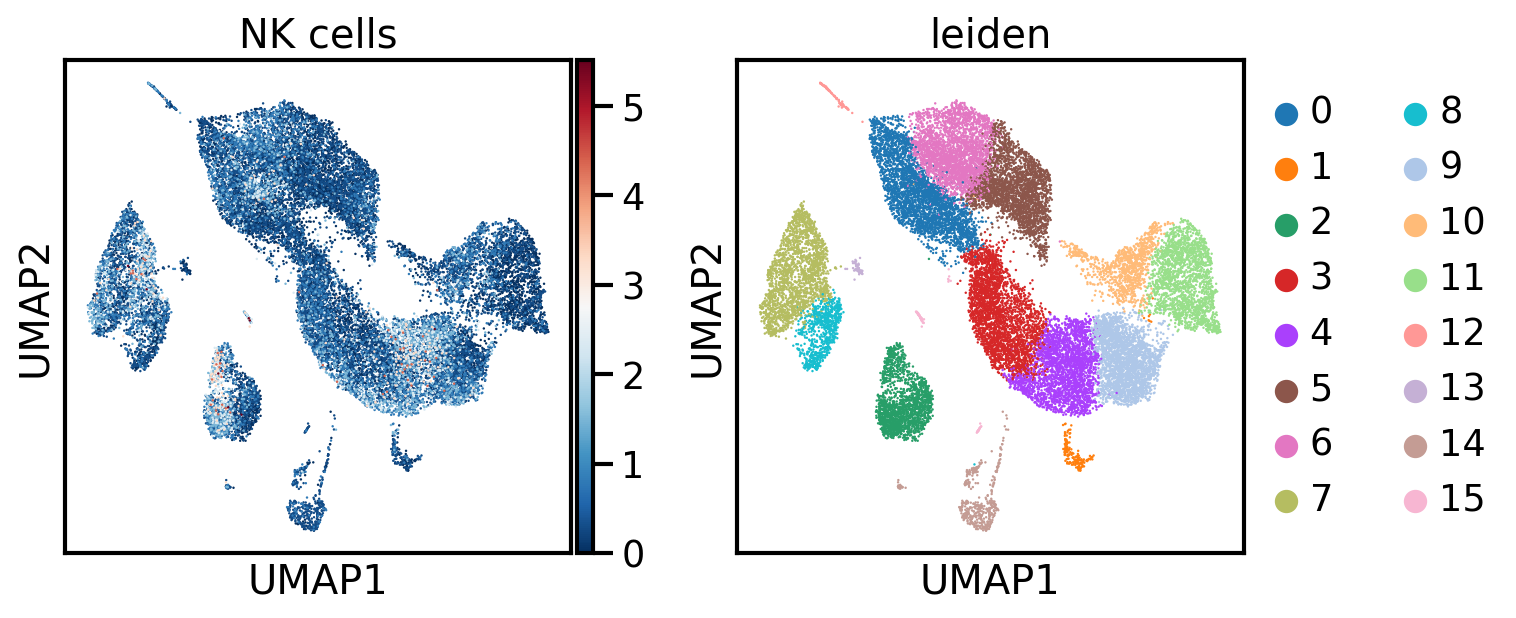

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

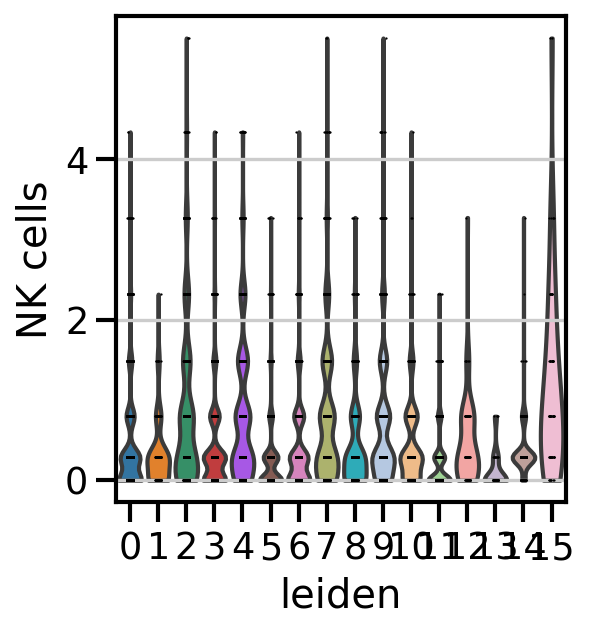

In [13]:
sc.pl.umap(acts, color=['NK cells', 'leiden'], cmap='RdBu_r')
sc.pl.violin(acts, keys=['NK cells'], groupby='leiden')

# Annotation

In [14]:
df = dc.rank_sources_groups(acts, groupby='leiden', reference='rest', method='t-test_overestim_var')
df

,group,reference,names,statistic,meanchange,pvals,pvals_adj
0,0,rest,Neutrophils,47.103725,2.583260,0.000000e+00,0.000000e+00
1,0,rest,Delta cells,23.628073,0.194340,3.405833e-117,2.179733e-116
2,0,rest,Gamma delta T cells,18.191502,0.160907,6.718100e-72,2.047421e-71
3,0,rest,Plasma cells,16.830202,0.156122,4.488180e-62,1.305652e-61
4,0,rest,Clara cells,10.821312,0.096781,4.684405e-27,9.084906e-27
...,...,...,...,...,...,...,...
1019,9,rest,Platelets,-17.585581,-0.256155,1.069317e-66,7.604031e-66
1020,9,rest,Cholangiocytes,-19.245979,-0.116008,8.582359e-79,7.846728e-78
1021,9,rest,Epithelial cells,-20.902029,-0.107498,2.480941e-91,2.646337e-90
1022,9,rest,Neutrophils,-21.861135,-0.914309,4.614501e-99,9.844268e-98


In [15]:
n_ctypes = 3
ctypes_dict = df.groupby('group').head(n_ctypes).groupby('group')['names'].apply(lambda x: list(x)).to_dict()
ctypes_dict

{'0': ['Neutrophils', 'Delta cells', 'Gamma delta T cells'],
 '1': ['Dendritic cells', 'Macrophages', 'Hepatocytes'],
 '10': ['Macrophages', 'Alpha cells', 'Pulmonary alveolar type II cells'],
 '11': ['Macrophages', 'Proximal tubule cells', 'Astrocytes'],
 '12': ['Platelets', 'Salivary mucous cells', 'Myoepithelial cells'],
 '13': ['Erythroid-like and erythroid precursor cells',
  'Peritubular myoid cells',
  'Goblet cells'],
 '14': ['Mesangial cells', 'Hepatic stellate cells', 'Endothelial cells'],
 '15': ['T cells', 'T memory cells', 'T cells naive'],
 '2': ['Keratinocytes', 'Clara cells', 'Acinar cells'],
 '3': ['Epithelial cells', 'Cholangiocytes', 'Enterocytes'],
 '4': ['Enterocytes', 'B cells', 'B cells naive'],
 '5': ['Cholangiocytes', 'Oligodendrocytes', 'Hepatocytes'],
 '6': ['Neutrophils', 'Ductal cells', 'Gamma delta T cells'],
 '7': ['Mast cells', 'Decidual cells', 'Platelets'],
 '8': ['Mast cells', 'Mesothelial cells', 'Adipocytes'],
 '9': ['B cells', 'B cells naive', 'Bet

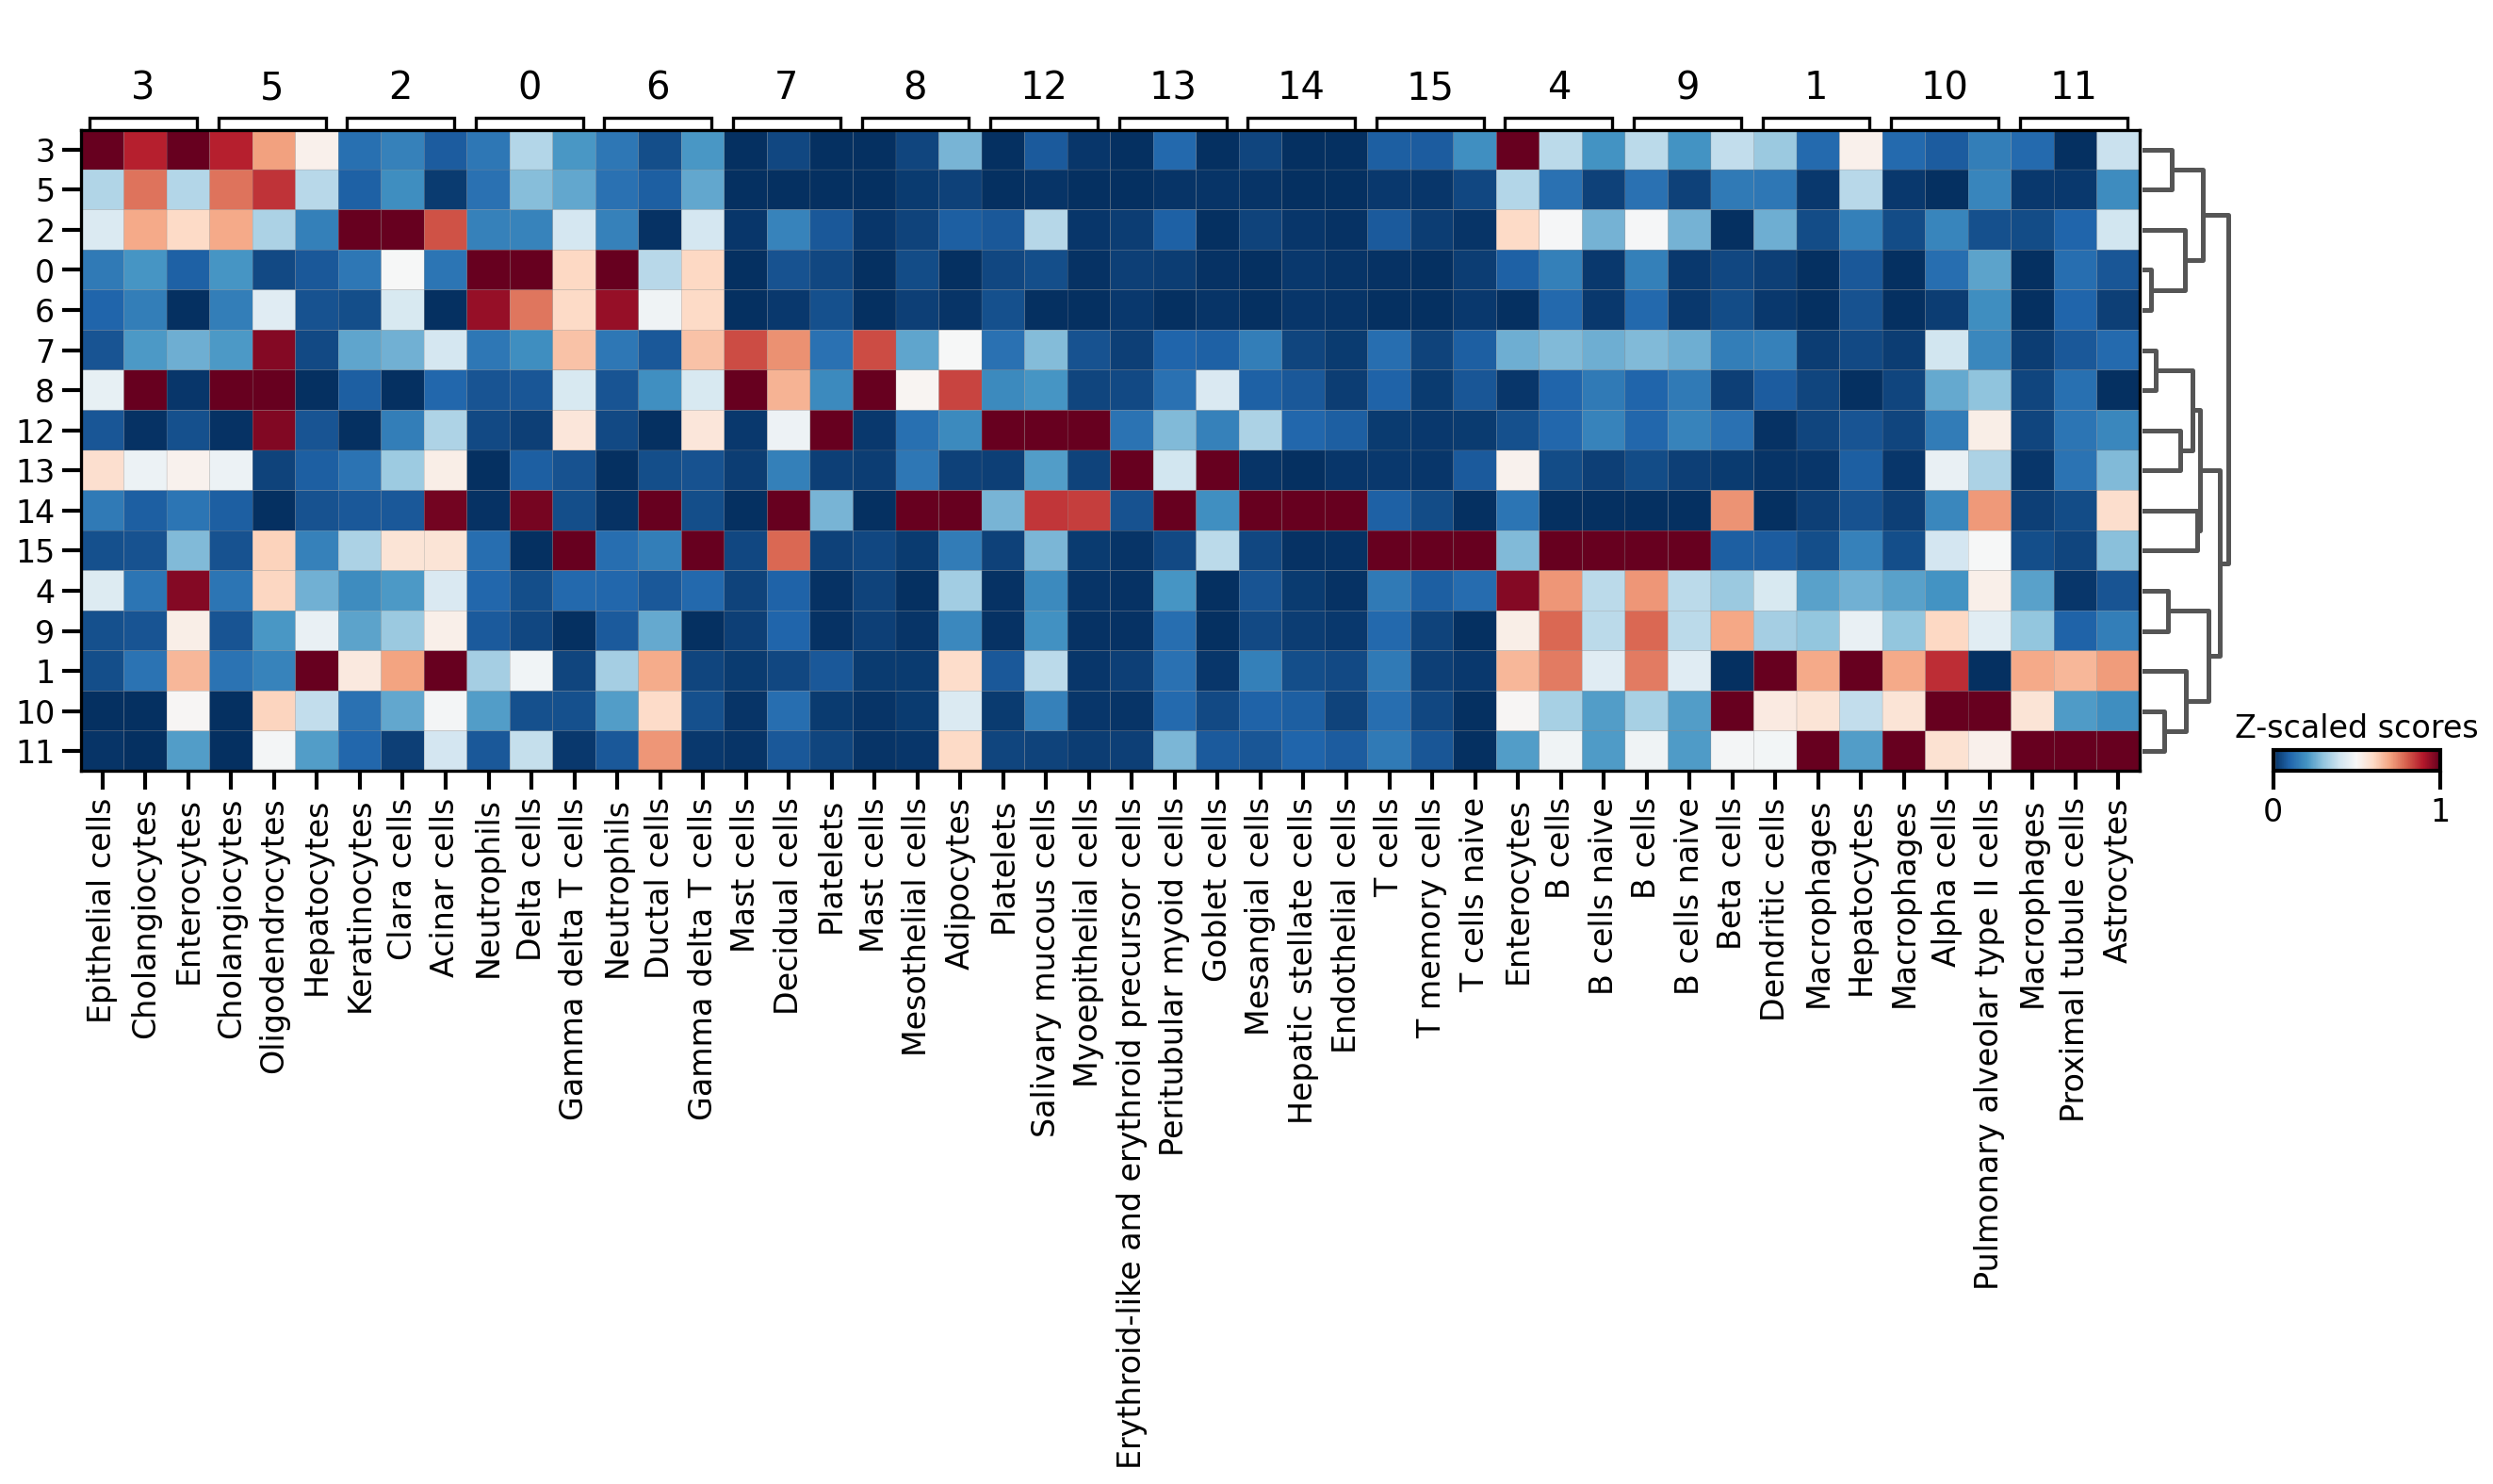

In [16]:
sc.pl.matrixplot(acts, ctypes_dict, 'leiden', dendrogram=True, standard_scale='var',
                 colorbar_title='Z-scaled scores', cmap='RdBu_r')

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

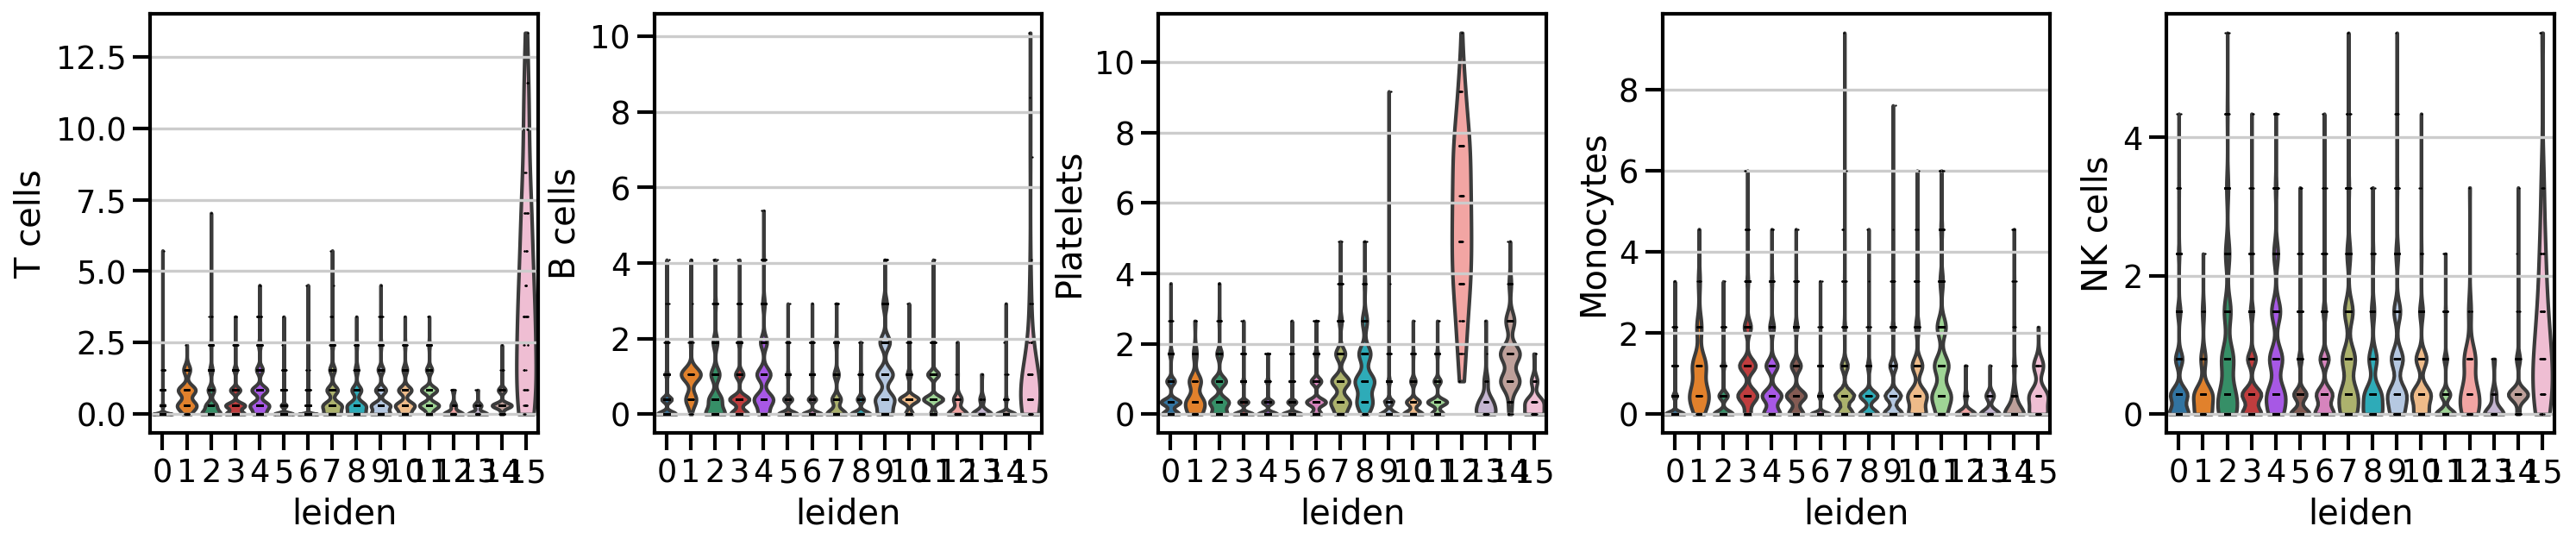

In [17]:
sc.pl.violin(acts, keys=['T cells', 'B cells', 'Platelets', 'Monocytes', 'NK cells'], groupby='leiden')

In [18]:
annotation_dict = df.groupby('group').head(1).set_index('group')['names'].to_dict()
annotation_dict

{'0': 'Neutrophils',
 '1': 'Dendritic cells',
 '10': 'Macrophages',
 '11': 'Macrophages',
 '12': 'Platelets',
 '13': 'Erythroid-like and erythroid precursor cells',
 '14': 'Mesangial cells',
 '15': 'T cells',
 '2': 'Keratinocytes',
 '3': 'Epithelial cells',
 '4': 'Enterocytes',
 '5': 'Cholangiocytes',
 '6': 'Neutrophils',
 '7': 'Mast cells',
 '8': 'Mast cells',
 '9': 'B cells'}

... storing 'cell_type' as categorical


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

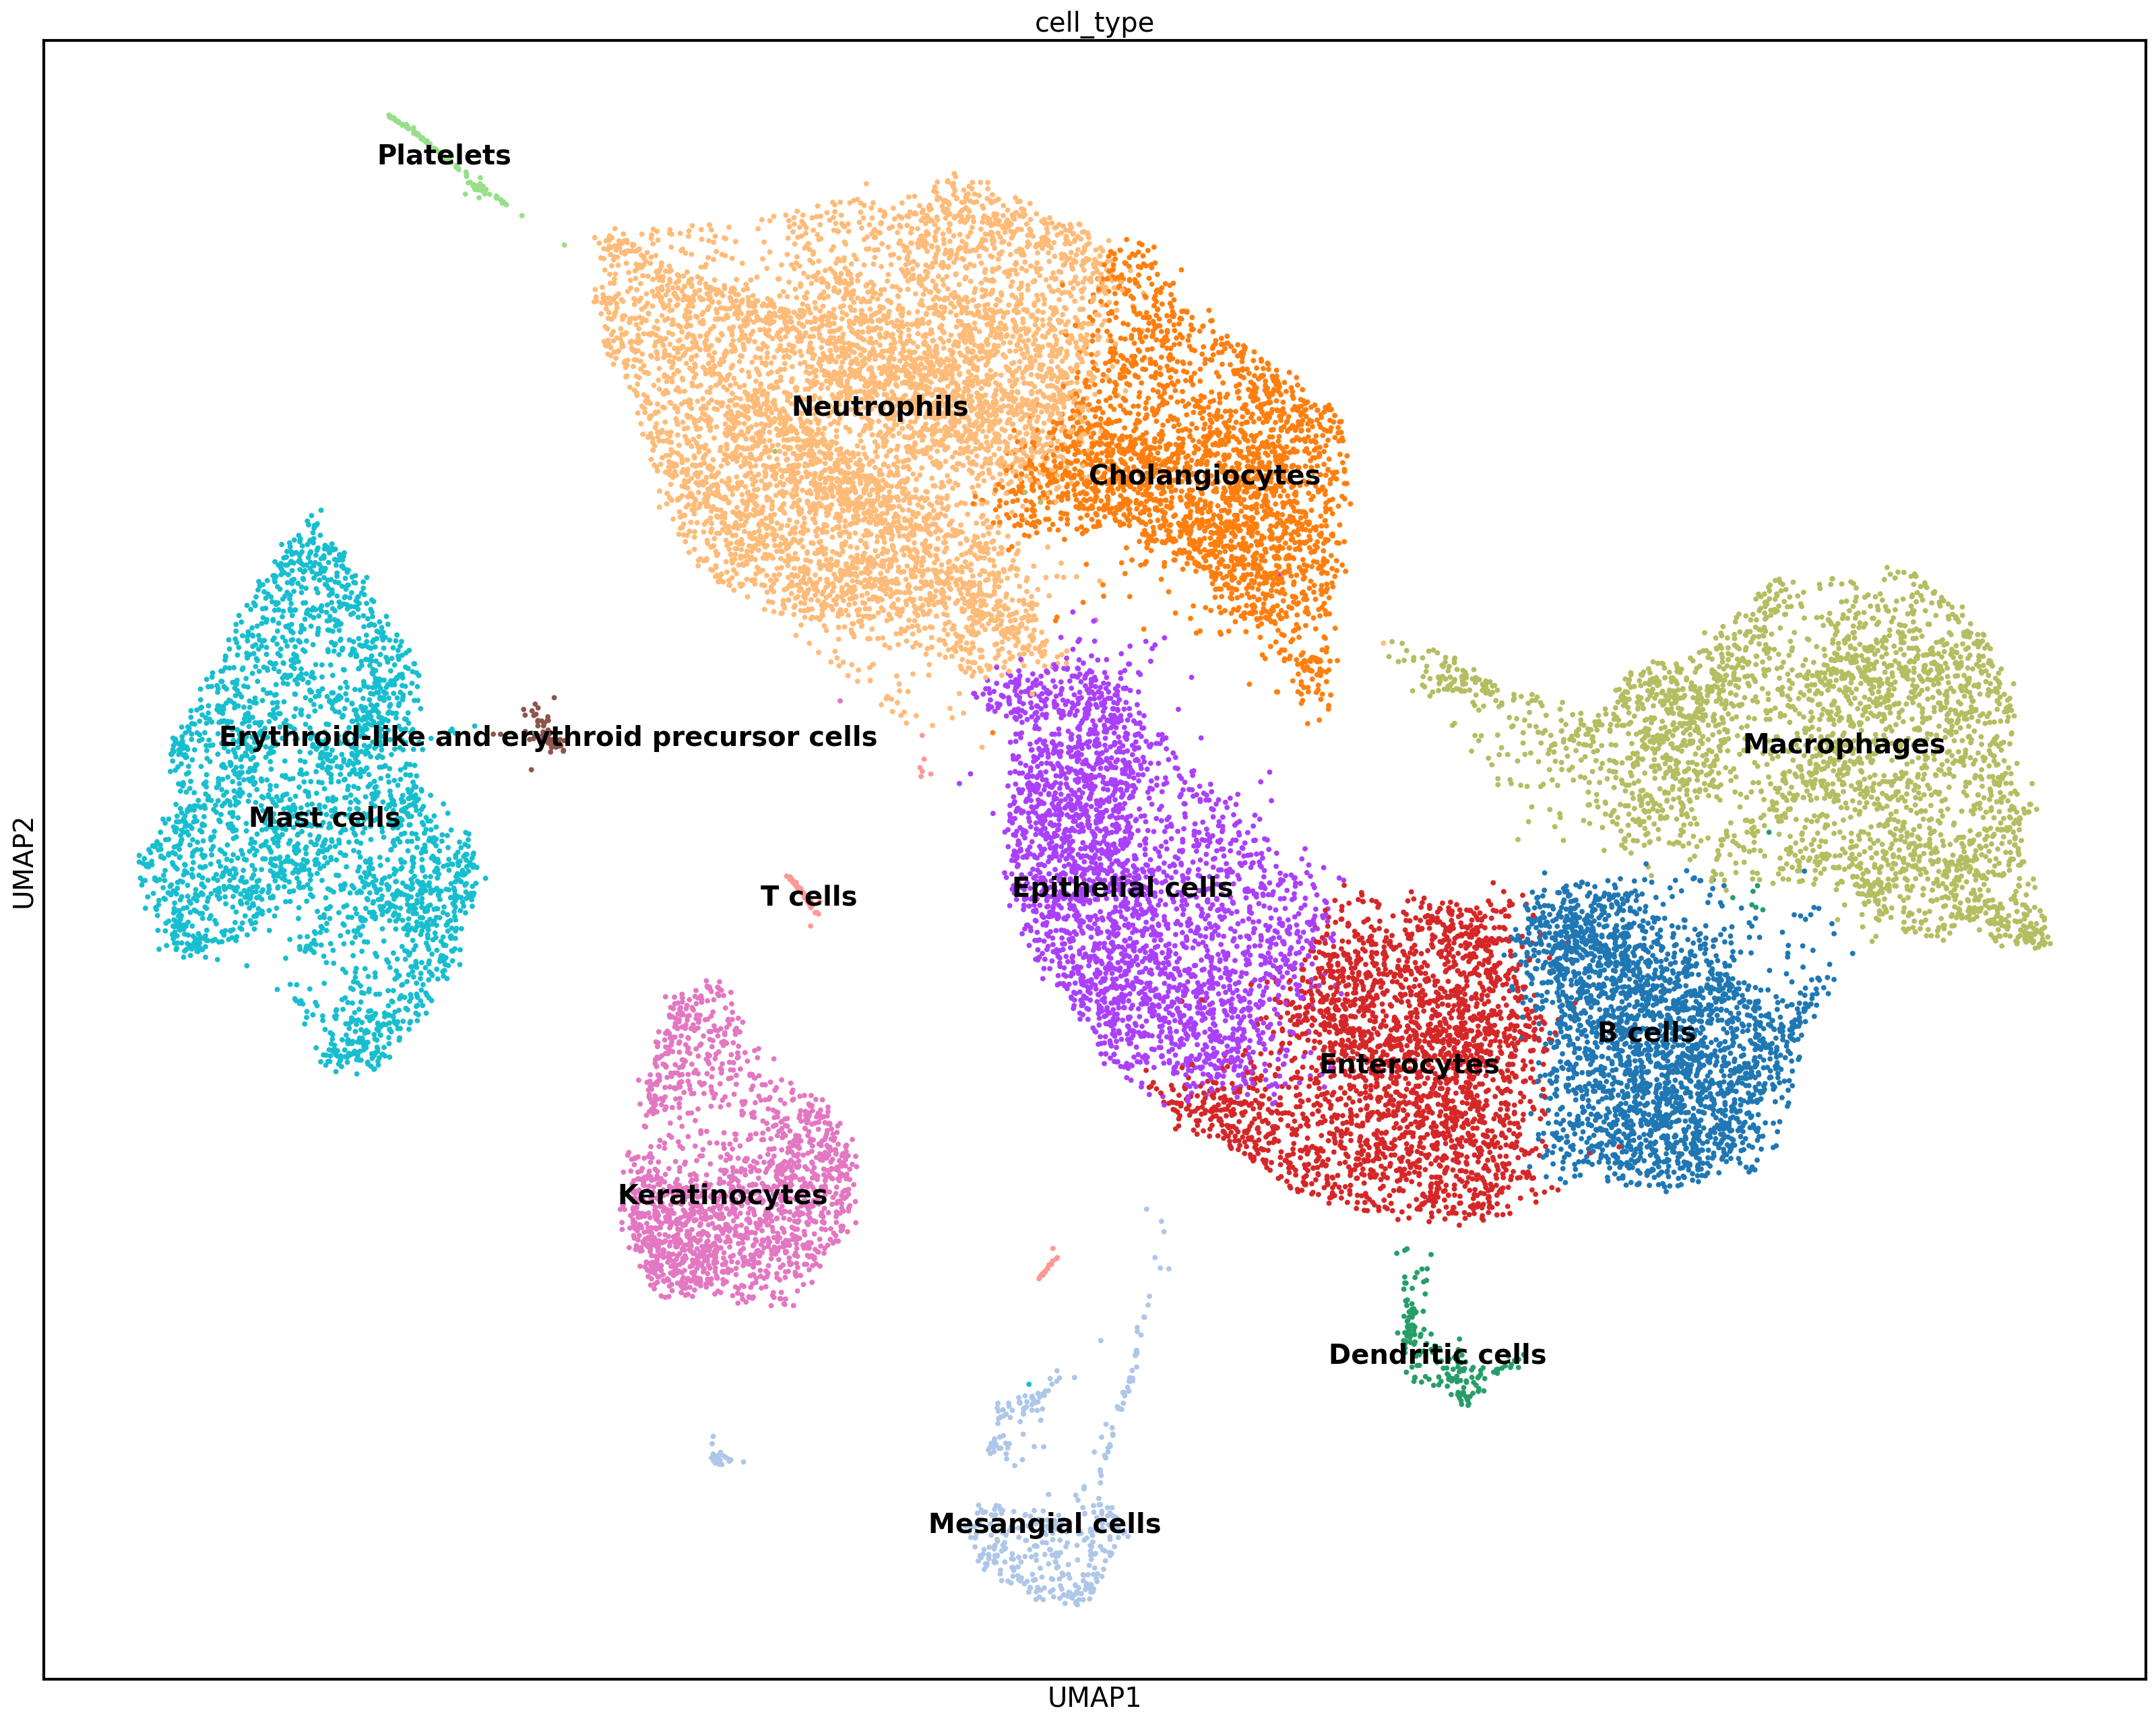

In [24]:
# Add cell type column based on annotation
wk2_adata.obs['cell_type'] = [annotation_dict[clust] for clust in wk2_adata.obs['leiden']]

fig, ax = plt.subplots(1, 1, figsize=(25, 20))

# Visualize
sc.pl.umap(
    wk2_adata,
    color='cell_type',
    legend_loc='on data',
    show=False,
    ax=ax,
    size=50
)